# Non-ergodic Mess3 — analysis

Loads what `experiments/nonergodic/train.py` saved to its `run/` directory and
plots. All probe fitting goes through `src.metrics.probes`; experiment-specific
analysis is in `src.nonergodic.analysis`; plotting is in `plots.nonergodic`.

Sections: training curve · belief decodability · telescope geometry (2D + 3D) ·
component-identity probe · effective readout (start→end) · direct unembedding
inspection · causal-test stub.


In [2]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

# this notebook lives in plots/; repo root is one level up
REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO not in sys.path: sys.path.insert(0, REPO)

from src.nonergodic import analysis as A
from plots import nonergodic as P

RUN = os.path.join(REPO, "experiments", "nonergodic", "run")

cfg = json.load(open(os.path.join(RUN, "config.json")))
hmm = np.load(os.path.join(RUN, "hmm.npz"))
hist = np.load(os.path.join(RUN, "train_history.npz"))
val = np.load(os.path.join(RUN, "val_data.npz"))
gt = np.load(os.path.join(RUN, "ground_truth.npz"))
act = np.load(os.path.join(RUN, "activations.npz"))
wts = np.load(os.path.join(RUN, "weights.npz"))

K = len(cfg["comp_params"]); S = cfg["n_states"]; V = cfg["vocab"]; L = cfg["seq_len"]
d = cfg["d_model"]
M_block = hmm["M_block"]; comp_params = hmm["comp_params"]
print("components:", comp_params.tolist())


components: [[0.05, 0.05], [0.9, 0.15]]


## 1. Training curve

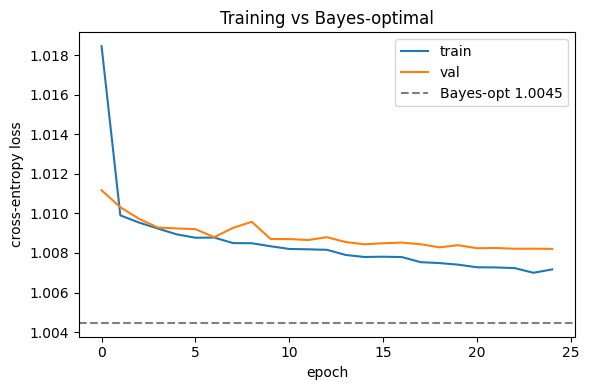

In [3]:
P.plot_training_curve(hist["train_loss"], hist["val_loss"], float(hist["opt_loss"]))
plt.tight_layout(); plt.show()

## 2. Telescoped-belief decodability  (via src.metrics.probes)

per-component test R²: {0: 0.699, 1: 0.779}


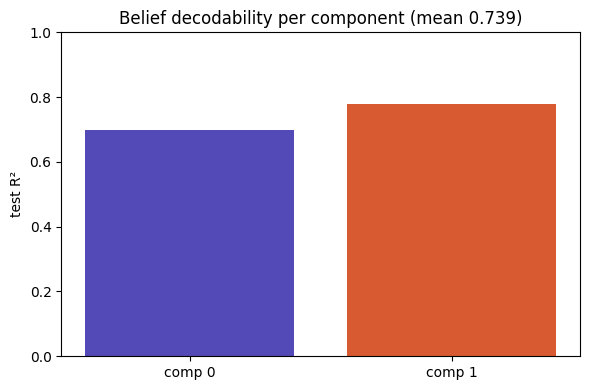

In [4]:
resid = act["resid_final"].reshape(-1, d)
B = gt["telescoped"].reshape(-1, K*S)
probe = A.decode_beliefs(resid, B, S, seed=0)
print("per-component test R²:", {c: round(r,3) for c,r in probe["per_block_r2"].items()})
P.plot_belief_r2(probe["per_block_r2"]); plt.tight_layout(); plt.show()

## 3. Telescope geometry

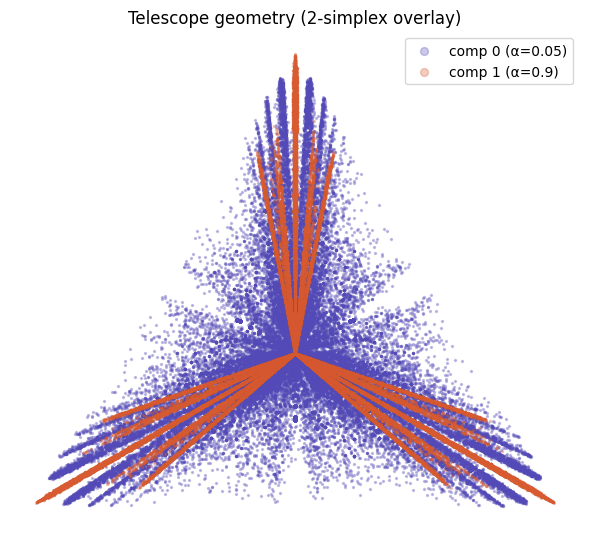

In [5]:
tel = gt["telescoped"].reshape(-1, K*S)
P.plot_telescope_2d(A.telescope_2d(tel, S), comp_params); plt.tight_layout(); plt.show()

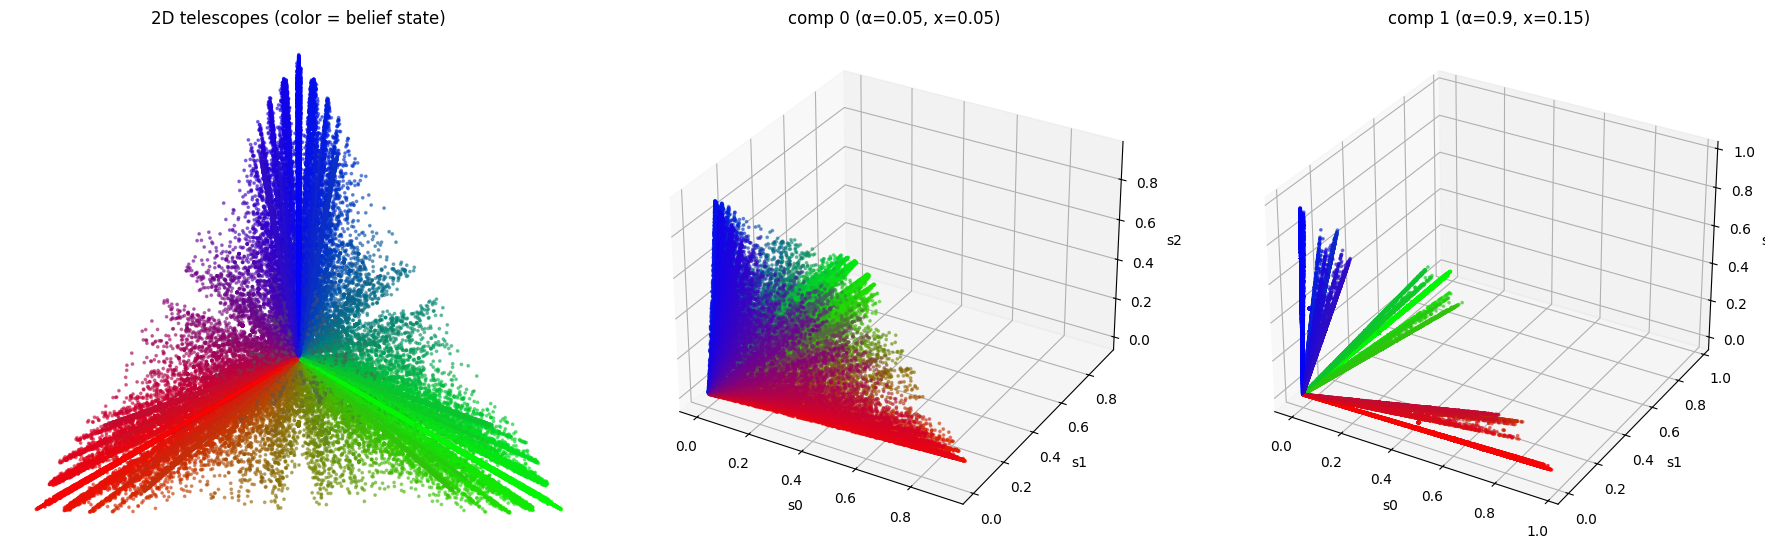

In [10]:
# Telescope geometry colored by belief state (RGB = simplex coords)
tel = gt["telescoped"].reshape(-1, K*S)

verts = np.array([[0,0],[1,0],[0.5,0.8660254]]); cen = verts.mean(0)

fig = plt.figure(figsize=(6*(K+1), 5.5))

# --- 2D overlay (all components on one simplex) ---
ax = fig.add_subplot(1, K+1, 1)
for n in range(K):
    blk = tel[:, n*S:(n+1)*S]
    w = blk.sum(1, keepdims=True)
    eta = np.divide(blk, w, out=np.zeros_like(blk), where=w>1e-9)
    xy = eta @ verts
    pts = cen + (xy - cen) * w                 # scale toward center by weight
    ax.scatter(pts[:,0], pts[:,1], s=3, c=np.clip(eta,0,1), alpha=0.5)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("2D telescopes (color = belief state)")

# --- 3D, one panel per component ---
for n in range(K):
    ax = fig.add_subplot(1, K+1, n+2, projection="3d")
    blk = tel[:, n*S:(n+1)*S]
    w = blk.sum(1, keepdims=True)
    eta = np.divide(blk, w, out=np.zeros_like(blk), where=w>1e-9)
    ax.scatter(blk[:,0], blk[:,1], blk[:,2], s=3, c=np.clip(eta,0,1), alpha=0.5)
    ax.set_title(f"comp {n} (α={comp_params[n][0]}, x={comp_params[n][1]})")
    ax.set_xlabel("s0"); ax.set_ylabel("s1"); ax.set_zlabel("s2")

plt.tight_layout(); plt.show()

## 4. Component-identity probe across positions  (via src.metrics.probes)

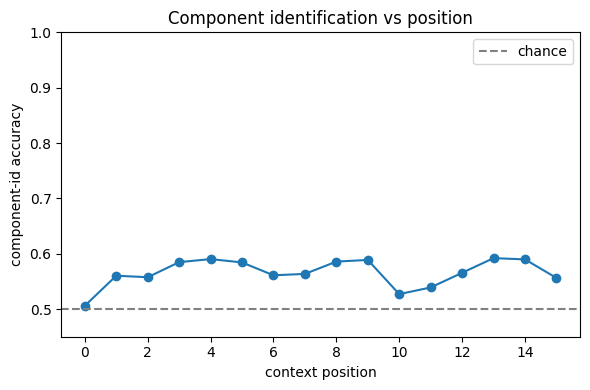

In [7]:
acc = A.component_probe_by_position(act["resid_final"], val["val_comps"], seed=0)
P.plot_component_probe(acc); plt.tight_layout(); plt.show()

## 5. Effective readout (start→end)

Fit (shared probe code) decoded belief -> model probs, column-center to remove
the sum-to-1 gauge, compare to the true block emission. This is the start→end
argument: shows the implied map is emission-shaped, not that the unembedding
mechanism implements it.

cosine(recovered, true block emission), centered: 1.0


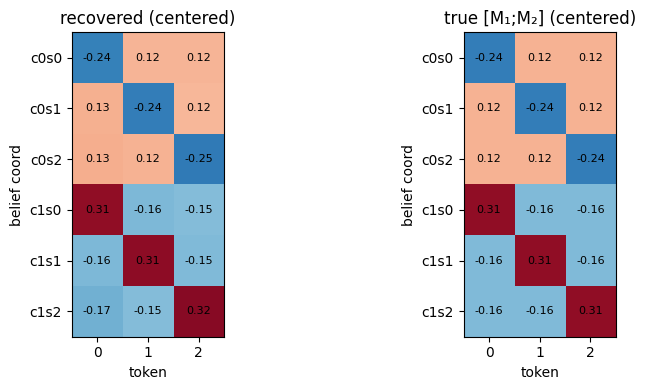

In [8]:
Pm = act["model_probs"].reshape(-1, V)
M_rec, M_rec_c = A.recover_readout(probe["decoded_all"], Pm)
print("cosine(recovered, true block emission), centered:",
      round(A.cosine(M_rec_c, A.col_center(M_block)), 3))
P.plot_readout_recovery(M_rec_c, A.col_center(M_block), S); plt.show()

## 6. Direct unembedding inspection

`logits = resid_final @ W_U`. Pull `W_U` back into belief coordinates: how much
of it lives in the belief subspace, and does its belief-relevant action match
the (log) emission matrix.

captured energy in belief subspace: 0.079 (random ~ 0.094, clean = 1.0)
reconstruction rel error          : 0.961
cosine(pullback, log-emission)    : 0.719
cosine(pullback, emission)        : 0.676


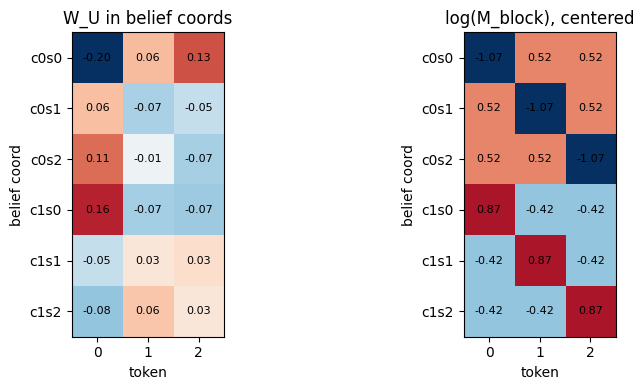

In [9]:
W_U = wts["W_U"].T
insp = A.inspect_unembedding(W_U, probe["W"], M_block)
print(f"captured energy in belief subspace: {insp['captured_energy']:.3f} "
      f"(random ~ {insp['random_baseline']:.3f}, clean = 1.0)")
print(f"reconstruction rel error          : {insp['recon_rel_err']:.3f}")
print(f"cosine(pullback, log-emission)    : {insp['cos_logM']:.3f}")
print(f"cosine(pullback, emission)        : {insp['cos_M']:.3f}")
P.plot_unembedding_inspection(insp["pullback_centered"], insp["logM_centered"], S); plt.show()

## 7. (stub) Causal test — next step

Clean test of "the unembedding implements the emission matrix" is causal: patch
one component's belief subspace and check the output shifts by exactly
`delta_eta_n @ M_n` (weighted by `w_n`). Sidesteps the LayerNorm nonlinearity and
the log-scale issue because you measure output deltas directly. Use the saved
`weights.npz` (W_U, LN params) and `activations.npz`.
